# Sprint 2 - Tracking longitudinal y transiciones de categoría

Este notebook desarrolla las tareas del Sprint 2 del proyecto:

**Tarea 1.** Tracking de individuos vía `ID_PERSONA_PR` entre convocatorias, para identificar cuántos suben de categoría, cuántos se mantienen, cuántos bajan y cuántos desaparecen.

**Tarea 2.** Cálculo de probabilidades de transición entre categorías `Junior`, `Asociado`, `Senior` y `Emérito` entre convocatorias consecutivas.


> **Versión comentada:** se añadieron explicaciones sencillas dentro de cada bloque de código para facilitar la lectura del notebook.

In [20]:
# Importamos las librerías principales del análisis.
# pandas: manipulación de tablas.
# numpy: operaciones numéricas (en este notebook finalmente casi no se usa).
# matplotlib.pyplot: gráficos sencillos para resumir resultados.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Preparación de la base analítica

En esta sección se carga la base consolidada del Sprint 1 y se construye una tabla mínima para el análisis longitudinal.

In [21]:
# Cargamos la base consolidada construida en el Sprint 1.
# Esta será la fuente para seguir a cada investigador entre convocatorias.
df = pd.read_csv("../../datos/tarea_join/investigadores_consolidado.csv")

# Mostramos las primeras filas para verificar que el archivo cargó bien.
df.head()

,ID_CONVOCATORIA,NME_CONVOCATORIA,ANO_CONVO,ID_PERSONA_PR,ID_AREA_CON_PR,NME_ESP_AREA_PR,NME_AREA_PR,NME_GRAN_AREA_PR,NME_GENERO_PR,NME_PAIS_NAC_PR,...,EDAD_ANOS_PR,NME_PAIS_RES_PR,NME_REGION_RES_PR,NME_DEPARTAMENTO_RES_PR,NME_MUNICIPIO_RES_PR,COD_DANE_RES_PR,ID_VICTIMA_CONFLICTO,TXT_GRUPO_ETNICO,TXT_POBLACION_DISCA,INST_FILIA
0,19,Convocatoria 781 de 2017,12/05/2017,20524,1C02,Física de la Materia,Ciencias Físicas,Ciencias Naturales,Masculino,Colombia,...,54.48,Colombia,Caribe,Atlántico,Barranquilla,8001.0,No registra,No disponible,No disponible,NaN
1,19,Convocatoria 781 de 2017,12/05/2017,83283,5D01,Sociología,Sociología,Ciencias Sociales,Masculino,Exterior,...,51.92,Colombia,Pacífico,Valle del Cauca,Cali,76001.0,No registra,No disponible,No disponible,UNIVERSIDAD DEL VALLE
2,19,Convocatoria 781 de 2017,12/05/2017,95702,1A01,Matemáticas Puras,Matemática,Ciencias Naturales,Masculino,Colombia,...,62.39,Colombia,Eje Cafetero,Antioquia,Medellín,5001.0,No registra,No disponible,No disponible,NaN
3,19,Convocatoria 781 de 2017,12/05/2017,95710,1A02,Matemáticas Aplicadas,Matemática,Ciencias Naturales,Masculino,Colombia,...,61.82,Colombia,Eje Cafetero,Antioquia,Medellín,5001.0,No registra,No disponible,No disponible,NaN
4,19,Convocatoria 781 de 2017,12/05/2017,95737,1A01,Matemáticas Puras,Matemática,Ciencias Naturales,Femenino,Colombia,...,59.60,Colombia,Eje Cafetero,Antioquia,Medellín,5001.0,No registra,No disponible,No disponible,NaN


In [22]:
# Revisamos los nombres de las columnas disponibles en la base original.
# Esto sirve para confirmar que existen las variables que vamos a usar.
df.columns.tolist()

['ID_CONVOCATORIA',
 'NME_CONVOCATORIA',
 'ANO_CONVO',
 'ID_PERSONA_PR',
 'ID_AREA_CON_PR',
 'NME_ESP_AREA_PR',
 'NME_AREA_PR',
 'NME_GRAN_AREA_PR',
 'NME_GENERO_PR',
 'NME_PAIS_NAC_PR',
 'NME_REGION_NAC_PR',
 'NME_DEPARTAMENTO_NAC_PR',
 'NME_MUNICIPIO_NAC_PR',
 'COD_DANE_NAC_PR',
 'ID_NIV_FORMACION_PR',
 'NME_NIV_FORM_PR',
 'NRO_ORDEN_FORM_PR',
 'ID_CLAS_PR',
 'NME_CLASIFICACION_PR',
 'ORDEN_CLAS_PR',
 'EDAD_ANOS_PR',
 'NME_PAIS_RES_PR',
 'NME_REGION_RES_PR',
 'NME_DEPARTAMENTO_RES_PR',
 'NME_MUNICIPIO_RES_PR',
 'COD_DANE_RES_PR',
 'ID_VICTIMA_CONFLICTO',
 'TXT_GRUPO_ETNICO',
 'TXT_POBLACION_DISCA',
 'INST_FILIA']

In [23]:
# Nos quedamos solo con las columnas necesarias para el análisis longitudinal:
# - ID_PERSONA_PR: identificador del investigador
# - ANO_CONVO: fecha de la convocatoria
# - NME_CLASIFICACION_PR: categoría textual
# - ORDEN_CLAS_PR: orden reportado en la base
base = df[["ID_PERSONA_PR", "ANO_CONVO", "NME_CLASIFICACION_PR", "ORDEN_CLAS_PR"]].copy()

# Convertimos la fecha de convocatoria a tipo fecha.
# errors="coerce" transforma valores mal escritos en NaT para poder detectarlos.
base["ANO_CONVO"] = pd.to_datetime(base["ANO_CONVO"], format="%d/%m/%Y", errors="coerce")

# Extraemos solo el año, porque las comparaciones se harán por convocatoria/año.
base["anio"] = base["ANO_CONVO"].dt.year

# Aseguramos que el orden de categoría sea numérico.
base["ORDEN_CLAS_PR"] = pd.to_numeric(base["ORDEN_CLAS_PR"], errors="coerce")

# Eliminamos filas sin información mínima para hacer el seguimiento.
# Si falta el ID, el año o la categoría, no podemos comparar trayectorias.
base = base.dropna(subset=["ID_PERSONA_PR", "ANO_CONVO", "anio", "NME_CLASIFICACION_PR"])

# Vista rápida de la base ya filtrada.
base.head()

,ID_PERSONA_PR,ANO_CONVO,NME_CLASIFICACION_PR,ORDEN_CLAS_PR,anio
0,20524,2017-05-12,Investigador Sénior,14,2017
1,83283,2017-05-12,Investigador Asociado,13,2017
2,95702,2017-05-12,Investigador Junior,12,2017
3,95710,2017-05-12,Investigador Sénior,14,2017
4,95737,2017-05-12,Investigador Asociado,13,2017


In [24]:
# Esta función estandariza los nombres de categoría.
# La base puede traer diferencias de mayúsculas, tildes o textos más largos;
# aquí las reducimos a cuatro categorías comparables.
def normalizar_categoria(x):
    # Convertimos a texto, quitamos espacios y pasamos a minúsculas.
    x = str(x).strip().lower()

    # Buscamos palabras clave y devolvemos una etiqueta estandarizada.
    if "junior" in x:
        return "Junior"
    elif "asociado" in x:
        return "Asociado"
    elif "sénior" in x or "senior" in x:
        return "Senior"
    elif "emérito" in x or "emerito" in x:
        return "Emérito"
    else:
        # Si no reconocemos la categoría, la marcamos como nula.
        return None

# Aplicamos la normalización sobre la categoría original.
base["categoria"] = base["NME_CLASIFICACION_PR"].apply(normalizar_categoria)

# Quitamos registros con categorías no reconocidas, porque no pueden entrar al análisis.
base = base.dropna(subset=["categoria"])

In [25]:
# Definimos un orden manual para las categorías.
# Este orden será clave para decidir si un investigador sube, baja o se mantiene.
orden_manual = {
    "Junior": 1,
    "Asociado": 2,
    "Senior": 3,
    "Emérito": 4
}

# Convertimos la categoría textual a una escala numérica ordinal.
base["orden"] = base["categoria"].map(orden_manual)

# Revisamos cómo quedó la tabla con la nueva variable 'orden'.
base.head()

,ID_PERSONA_PR,ANO_CONVO,NME_CLASIFICACION_PR,ORDEN_CLAS_PR,anio,categoria,orden
0,20524,2017-05-12,Investigador Sénior,14,2017,Senior,3
1,83283,2017-05-12,Investigador Asociado,13,2017,Asociado,2
2,95702,2017-05-12,Investigador Junior,12,2017,Junior,1
3,95710,2017-05-12,Investigador Sénior,14,2017,Senior,3
4,95737,2017-05-12,Investigador Asociado,13,2017,Asociado,2


## Verificación de calidad de la base

Se revisa la estructura temporal de la convocatoria, las categorías de clasificación y la unicidad de los registros por investigador y año.

In [26]:
# Verificamos qué años de convocatoria quedaron en la base analítica.
# Esto confirma entre qué periodos sí es posible hacer comparaciones.
sorted(base["anio"].dropna().unique().tolist())

[2017, 2019, 2021]

In [27]:
# Comparamos la categoría normalizada con el orden reportado en la base.
# Esto sirve como chequeo de consistencia antes de seguir con el tracking.
base[["categoria", "ORDEN_CLAS_PR"]].drop_duplicates().sort_values("ORDEN_CLAS_PR")

,categoria,ORDEN_CLAS_PR
2,Junior,12
1,Asociado,13
0,Senior,14
35,Emérito,15


In [28]:
# Buscamos posibles duplicados por investigador y año.
# Idealmente debe existir una sola observación por ID_PERSONA_PR en cada convocatoria.
duplicados = (
    base.groupby(["ID_PERSONA_PR", "anio"])
        .size()
        .reset_index(name="n")
)

# Mostramos solo los casos problemáticos (más de un registro por persona y año).
duplicados[duplicados["n"] > 1].head(20)

,ID_PERSONA_PR,anio,n


In [29]:
# Construimos una tabla cruzada año vs. categoría.
# Esto permite ver cuántos investigadores hay en cada categoría por convocatoria.
pd.crosstab(base["anio"], base["categoria"])

categoria,Asociado,Emérito,Junior,Senior
anio,,,,
2017,3595,124,7575,1707
2019,4349,53,9921,2473
2021,4601,83,13370,3040


La base analítica quedó estructurada con una observación por investigador y año, sin duplicados por `ID_PERSONA_PR` y `anio`. Esto permite realizar el análisis longitudinal sin sobreconteo.

# Tarea 1 - Tracking longitudinal de investigadores

En esta sección se compara la trayectoria de los investigadores entre convocatorias consecutivas usando `ID_PERSONA_PR`.  
El objetivo es cuantificar cuántos investigadores:

- suben de categoría,
- se mantienen,
- bajan,
- o desaparecen de la siguiente convocatoria.

In [30]:
# Esta función compara dos convocatorias para los mismos investigadores.
# La idea es tomar un año inicial y buscar qué pasó con esas mismas personas
# en un año final.
def comparar_periodo(df, anio_inicial, anio_final):
    # Tabla del año inicial: contiene la categoría de partida de cada investigador.
    t0 = (
        df[df["anio"] == anio_inicial][["ID_PERSONA_PR", "categoria", "orden"]]
        .rename(columns={
            "categoria": "categoria_inicial",
            "orden": "orden_inicial"
        })
    )

    # Tabla del año final: contiene la categoría observada en el segundo año.
    t1 = (
        df[df["anio"] == anio_final][["ID_PERSONA_PR", "categoria", "orden"]]
        .rename(columns={
            "categoria": "categoria_final",
            "orden": "orden_final"
        })
    )

    # Hacemos un left join para conservar a todos los investigadores del año inicial.
    # Si alguien no aparece en el año final, quedará con NA y luego se clasifica como "Desaparece".
    comp = t0.merge(t1, on="ID_PERSONA_PR", how="left")

    # Esta función interna clasifica el resultado del seguimiento para cada investigador.
    def clasificar(row):
        # Si no aparece en la segunda convocatoria, se marca como "Desaparece".
        if pd.isna(row["categoria_final"]):
            return "Desaparece"
        # Si el orden final es mayor, significa que avanzó a una categoría superior.
        elif row["orden_final"] > row["orden_inicial"]:
            return "Sube"
        # Si el orden final es menor, retrocedió en la clasificación.
        elif row["orden_final"] < row["orden_inicial"]:
            return "Baja"
        # Si el orden no cambia, permanece en la misma categoría.
        else:
            return "Se mantiene"

    # Aplicamos la clasificación fila por fila.
    comp["resultado"] = comp.apply(clasificar, axis=1)

    # Guardamos una etiqueta del periodo para facilitar lectura/exportación.
    comp["periodo"] = f"{anio_inicial}_{anio_final}"

    return comp


# Esta función resume el tracking: cuenta cuántos casos hay en cada resultado.
def resumen_tracking(comp):
    return (
        comp["resultado"]
        .value_counts()
        .rename_axis("resultado")
        .reset_index(name="n")
    )

In [31]:
# Ejecutamos la comparación para los dos periodos de interés:
# 2017 -> 2019
# 2019 -> 2021
comp_17_19 = comparar_periodo(base, 2017, 2019)
comp_19_21 = comparar_periodo(base, 2019, 2021)

# Calculamos un resumen general de cada periodo.
resumen_17_19 = resumen_tracking(comp_17_19)
resumen_19_21 = resumen_tracking(comp_19_21)

# Mostramos el resumen del primer periodo.
resumen_17_19

,resultado,n
0,Se mantiene,7018
1,Desaparece,3007
2,Sube,2246
3,Baja,730


In [32]:
# Mostramos el resumen del segundo periodo para comparar patrones.
resumen_19_21

,resultado,n
0,Se mantiene,9657
1,Desaparece,3441
2,Sube,2336
3,Baja,1362


In [33]:
# Calculamos el porcentaje que representa cada resultado dentro del periodo.
# Esto ayuda a comparar periodos incluso si el total de investigadores cambia.
resumen_17_19["porcentaje"] = (resumen_17_19["n"] / resumen_17_19["n"].sum()).round(4)
resumen_19_21["porcentaje"] = (resumen_19_21["n"] / resumen_19_21["n"].sum()).round(4)

# Revisamos el resumen con porcentajes para 2017-2019.
resumen_17_19

,resultado,n,porcentaje
0,Se mantiene,7018,0.5398
1,Desaparece,3007,0.2313
2,Sube,2246,0.1728
3,Baja,730,0.0561


In [34]:
# Revisamos el resumen con porcentajes para 2019-2021.
resumen_19_21

,resultado,n,porcentaje
0,Se mantiene,9657,0.5750
1,Desaparece,3441,0.2049
2,Sube,2336,0.1391
3,Baja,1362,0.0811


In [35]:
# Desagregamos el tracking por categoría inicial.
# Así podemos responder preguntas como:
# "¿desde qué categoría se observa más permanencia, más ascenso o más desaparición?"
tabla_cat_17_19 = comp_17_19.groupby(["categoria_inicial", "resultado"]).size().unstack(fill_value=0)
tabla_cat_19_21 = comp_19_21.groupby(["categoria_inicial", "resultado"]).size().unstack(fill_value=0)

# Mostramos la tabla del primer periodo.
tabla_cat_17_19

resultado,Baja,Desaparece,Se mantiene,Sube
categoria_inicial,,,,
Asociado,558,505,1793,739
Emérito,0,124,0,0
Junior,0,2300,3797,1478
Senior,172,78,1428,29


In [36]:
# Mostramos la tabla equivalente para 2019-2021.
tabla_cat_19_21

resultado,Baja,Desaparece,Se mantiene,Sube
categoria_inicial,,,,
Asociado,960,501,2171,717
Emérito,0,53,0,0
Junior,0,2789,5558,1574
Senior,402,98,1928,45


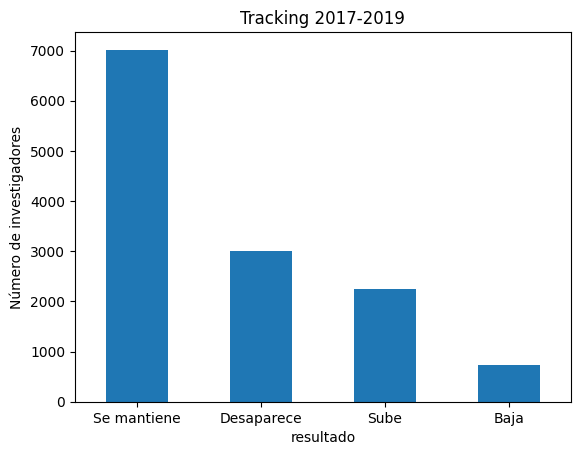

In [37]:
# Graficamos el resumen del tracking 2017-2019.
# Cada barra representa cuántos investigadores se mantienen, suben, bajan o desaparecen.
resumen_17_19.plot(kind="bar", x="resultado", y="n", legend=False)
plt.title("Tracking 2017-2019")
plt.ylabel("Número de investigadores")
plt.xticks(rotation=0)
plt.show()

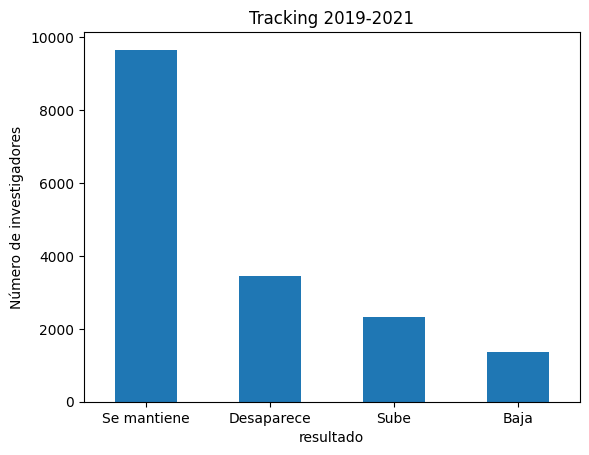

In [38]:
# Repetimos el gráfico para el periodo 2019-2021.
resumen_19_21.plot(kind="bar", x="resultado", y="n", legend=False)
plt.title("Tracking 2019-2021")
plt.ylabel("Número de investigadores")
plt.xticks(rotation=0)
plt.show()

## Interpretación de la Tarea 1

Entre 2017 y 2019, la mayor parte de los investigadores se mantuvo en la misma categoría, seguida por quienes desaparecen de la siguiente convocatoria. Los ascensos fueron más frecuentes que los descensos.

Entre 2019 y 2021 también predominó la permanencia, aunque se observa una disminución relativa de los ascensos y un aumento de los descensos frente al periodo anterior.

En ambos periodos, la desaparición entre convocatorias representa una fracción importante del total de investigadores observados.

# Tarea 2 - Probabilidades de transición entre categorías

En esta sección se calculan matrices de transición entre categorías de investigadores para convocatorias consecutivas.

Se presentan dos enfoques:

1. Matriz de transición entre categorías observadas en ambas convocatorias.
2. Matriz de transición extendida, incorporando el estado `Desaparece` para capturar la salida del panel.

In [39]:
# Esta función construye la matriz de transición "observada".
# Solo usa investigadores presentes en ambos años del periodo.
def matriz_transicion_observada(comp):
    # Eliminamos los que no tienen categoría final, es decir, los que desaparecen.
    temp = comp.dropna(subset=["categoria_final"]).copy()

    # La tabla cruzada cuenta cuántos pasan de una categoría inicial a una final.
    conteos = pd.crosstab(
        temp["categoria_inicial"],
        temp["categoria_final"]
    )

    # Convertimos los conteos en probabilidades por fila.
    # Cada fila suma 1 y se interpreta como distribución condicional
    # dada la categoría inicial.
    probabilidades = conteos.div(conteos.sum(axis=1), axis=0)

    return conteos, probabilidades


# Esta función construye una versión extendida de la matriz.
# Aquí sí incluimos a quienes no aparecen en el año final como estado "Desaparece".
def matriz_transicion_extendida(comp):
    temp = comp.copy()

    # Reemplazamos la categoría final faltante por la etiqueta "Desaparece".
    temp["categoria_final_ext"] = temp["categoria_final"].fillna("Desaparece")

    conteos = pd.crosstab(
        temp["categoria_inicial"],
        temp["categoria_final_ext"]
    )

    # Igual que antes, normalizamos por fila para obtener probabilidades.
    probabilidades = conteos.div(conteos.sum(axis=1), axis=0)

    return conteos, probabilidades

In [40]:
# Calculamos conteos y probabilidades de transición observada para ambos periodos.
conteos_17_19, probs_17_19 = matriz_transicion_observada(comp_17_19)
conteos_19_21, probs_19_21 = matriz_transicion_observada(comp_19_21)

# Mostramos la matriz de conteos 2017-2019.
conteos_17_19

categoria_final,Asociado,Emérito,Junior,Senior
categoria_inicial,,,,
Asociado,1793,13,558,726
Junior,1283,3,3797,192
Senior,91,29,81,1428


In [41]:
# Mostramos la matriz de probabilidades 2017-2019.
# El redondeo solo mejora la lectura; no cambia el cálculo original.
probs_17_19.round(4)

categoria_final,Asociado,Emérito,Junior,Senior
categoria_inicial,,,,
Asociado,0.5803,0.0042,0.1806,0.2350
Junior,0.2432,0.0006,0.7198,0.0364
Senior,0.0559,0.0178,0.0497,0.8766


In [42]:
# Mostramos la matriz de conteos para 2019-2021.
conteos_19_21

categoria_final,Asociado,Emérito,Junior,Senior
categoria_inicial,,,,
Asociado,2171,16,960,701
Junior,1276,7,5558,291
Senior,314,45,88,1928


In [43]:
# Mostramos la matriz de probabilidades para 2019-2021.
probs_19_21.round(4)

categoria_final,Asociado,Emérito,Junior,Senior
categoria_inicial,,,,
Asociado,0.5642,0.0042,0.2495,0.1822
Junior,0.1789,0.0010,0.7793,0.0408
Senior,0.1322,0.0189,0.0371,0.8118


In [44]:
# Calculamos ahora la matriz extendida, donde el estado "Desaparece"
# también cuenta como destino posible.
conteos_ext_17_19, probs_ext_17_19 = matriz_transicion_extendida(comp_17_19)
conteos_ext_19_21, probs_ext_19_21 = matriz_transicion_extendida(comp_19_21)

# Mostramos los conteos extendidos del primer periodo.
conteos_ext_17_19

categoria_final_ext,Asociado,Desaparece,Emérito,Junior,Senior
categoria_inicial,,,,,
Asociado,1793,505,13,558,726
Emérito,0,124,0,0,0
Junior,1283,2300,3,3797,192
Senior,91,78,29,81,1428


In [45]:
# Mostramos las probabilidades extendidas para 2017-2019.
probs_ext_17_19.round(4)

categoria_final_ext,Asociado,Desaparece,Emérito,Junior,Senior
categoria_inicial,,,,,
Asociado,0.4987,0.1405,0.0036,0.1552,0.2019
Emérito,0.0000,1.0000,0.0000,0.0000,0.0000
Junior,0.1694,0.3036,0.0004,0.5013,0.0253
Senior,0.0533,0.0457,0.0170,0.0475,0.8366


In [46]:
# Mostramos los conteos extendidos para 2019-2021.
conteos_ext_19_21

categoria_final_ext,Asociado,Desaparece,Emérito,Junior,Senior
categoria_inicial,,,,,
Asociado,2171,501,16,960,701
Emérito,0,53,0,0,0
Junior,1276,2789,7,5558,291
Senior,314,98,45,88,1928


In [47]:
# Mostramos las probabilidades extendidas para 2019-2021.
probs_ext_19_21.round(4)

categoria_final_ext,Asociado,Desaparece,Emérito,Junior,Senior
categoria_inicial,,,,,
Asociado,0.4992,0.1152,0.0037,0.2207,0.1612
Emérito,0.0000,1.0000,0.0000,0.0000,0.0000
Junior,0.1286,0.2811,0.0007,0.5602,0.0293
Senior,0.1270,0.0396,0.0182,0.0356,0.7796


In [48]:
# Revisamos específicamente qué pasó con quienes empezaban como Emérito en 2017.
# Esto ayuda a interpretar por qué esa categoría puede comportarse distinto.
comp_17_19[comp_17_19["categoria_inicial"] == "Emérito"]["resultado"].value_counts(dropna=False)

resultado
Desaparece    124
Name: count, dtype: int64

In [49]:
# Repetimos la misma revisión para quienes empezaban como Emérito en 2019.
comp_19_21[comp_19_21["categoria_inicial"] == "Emérito"]["resultado"].value_counts(dropna=False)

resultado
Desaparece    53
Name: count, dtype: int64

## Interpretación de la Tarea 2

Las matrices de transición muestran que la permanencia en la misma categoría es el resultado más frecuente entre convocatorias. La categoría Senior presenta la mayor estabilidad, mientras que Junior y Asociado concentran la mayor movilidad.

La matriz observada entre categorías no muestra la fila Emérito, no porque la categoría no exista en la base, sino porque todos los investigadores Emérito del periodo inicial desaparecen en la convocatoria siguiente.

Por esta razón, se construyó adicionalmente una matriz extendida con el estado `Desaparece`, lo cual permite representar de forma completa la salida del panel y mostrar correctamente el comportamiento longitudinal de la categoría Emérito.

In [50]:
# Exportamos todos los resultados a la carpeta de evidencias.
# Así quedan listos para el informe, el repositorio o el README.
resumen_17_19.to_csv("../../evidencias/resumen_tracking_2017_2019.csv", index=False)
resumen_19_21.to_csv("../../evidencias/resumen_tracking_2019_2021.csv", index=False)

tabla_cat_17_19.to_csv("../../evidencias/tracking_por_categoria_2017_2019.csv")
tabla_cat_19_21.to_csv("../../evidencias/tracking_por_categoria_2019_2021.csv")

conteos_17_19.to_csv("../../evidencias/matriz_transicion_2017_2019.csv")
conteos_19_21.to_csv("../../evidencias/matriz_transicion_2019_2021.csv")

probs_17_19.to_csv("../../evidencias/matriz_probabilidades_2017_2019.csv")
probs_19_21.to_csv("../../evidencias/matriz_probabilidades_2019_2021.csv")

conteos_ext_17_19.to_csv("../../evidencias/matriz_transicion_extendida_2017_2019.csv")
conteos_ext_19_21.to_csv("../../evidencias/matriz_transicion_extendida_2019_2021.csv")

probs_ext_17_19.to_csv("../../evidencias/matriz_probabilidades_extendida_2017_2019.csv")
probs_ext_19_21.to_csv("../../evidencias/matriz_probabilidades_extendida_2019_2021.csv")

# Conclusión general

El análisis longitudinal por `ID_PERSONA_PR` muestra que la permanencia en la misma categoría es el resultado más frecuente entre convocatorias. También se observa una proporción importante de investigadores que desaparecen de la convocatoria siguiente.

Las probabilidades de transición indican que Senior es la categoría más estable, Junior presenta alta permanencia con posibilidad de ascenso a Asociado, y Asociado funciona como una categoría intermedia con movilidad tanto ascendente como descendente.

Finalmente, aunque la categoría Emérito sí está presente en la base, no presenta continuidad en los periodos analizados dentro del panel emparejado, por lo que su comportamiento se representa correctamente en la matriz extendida con el estado `Desaparece`.